## **03. Modélisation & Tuning — Conversion Rate Challenge**

**Objectif** : entraîner les modèles, optimiser le seuil de décision, évaluer sur la validation.

**Métrique cible** : F1-score (imposé par la compétition)

**Plan du notebook** :
1. Chargement des données preprocessées
2. Baseline - Logistic Regression
3. Modèle principal — XGBoost
4. Modèle alternatif — LightGBM
5. Comparaison des modèles
6. Optimisation du seuil de décision
7. Évaluation finale - matrice de confusion
8. Feature Importance
9. Sauvegarde du meilleur modèle

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, precision_recall_curve,
                              roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pickle, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
output_model_path = '../outputs/models'
output_data_path = '../outputs/data'
output_processed_path = '../outputs/processed'
output_image_path = '../outputs/images'

### **1. Chargement des données preprocessées**

In [3]:
X_train = np.load(f'{output_processed_path}/X_train.npy')
X_val   = np.load(f'{output_processed_path}/X_val.npy')
y_train = pd.read_csv(f'{output_processed_path}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{output_processed_path}/y_val.csv').squeeze()

feature_names = ['age', 'total_pages_visited', 'country', 'source',
                 'new_user', 'high_engagement', 'is_returning', 'is_china']

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'X_train : {X_train.shape} | X_val : {X_val.shape}')
print(f'Ratio négatif/positif (scale_pos_weight) : {ratio:.1f}')

X_train : (227664, 8) | X_val : (56916, 8)
Ratio négatif/positif (scale_pos_weight) : 30.0


### **2. Baseline — Logistic Regression**

`class_weight='balanced'` pour gérer le déséquilibre 30:1.

In [4]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
logreg.fit(X_train, y_train)

y_proba_lr = logreg.predict_proba(X_val)[:, 1]
y_pred_lr  = logreg.predict(X_val)

print(f'F1-score : {f1_score(y_val, y_pred_lr):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_val, y_proba_lr):.4f}')
print()
print(classification_report(y_val, y_pred_lr))

F1-score : 0.5113
ROC-AUC : 0.9869

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55080
           1       0.35      0.95      0.51      1836

    accuracy                           0.94     56916
   macro avg       0.67      0.94      0.74     56916
weighted avg       0.98      0.94      0.95     56916



### **3. Modèle principal — XGBoost**

`scale_pos_weight=ratio` équivaut à `class_weight='balanced'` pour XGBoost.

In [5]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_proba_xgb = xgb.predict_proba(X_val)[:, 1]
y_pred_xgb  = xgb.predict(X_val)

print(f'F1-score : {f1_score(y_val, y_pred_xgb):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_val, y_proba_xgb):.4f}')
print()
print(classification_report(y_val, y_pred_xgb))

F1-score : 0.5187
ROC-AUC : 0.9855

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55080
           1       0.36      0.94      0.52      1836

    accuracy                           0.94     56916
   macro avg       0.68      0.94      0.74     56916
weighted avg       0.98      0.94      0.96     56916



### **4. Modèle alternatif — LightGBM**

In [6]:
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=-1
)
lgbm.fit(X_train, y_train)

y_proba_lgbm = lgbm.predict_proba(X_val)[:, 1]
y_pred_lgbm  = lgbm.predict(X_val)

print(f'F1-score : {f1_score(y_val, y_pred_lgbm):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_val, y_proba_lgbm):.4f}')
print()
print(classification_report(y_val, y_pred_lgbm))

F1-score : 0.5251
ROC-AUC : 0.9857

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     55080
           1       0.36      0.94      0.53      1836

    accuracy                           0.95     56916
   macro avg       0.68      0.94      0.75     56916
weighted avg       0.98      0.95      0.96     56916



### **5. Comparaison des modèles (seuil 0.5)**

,F1-score,ROC-AUC
LogReg(baseline),0.5113,0.9869
XGBoost,0.5187,0.9855
LightGBM,0.5251,0.9857


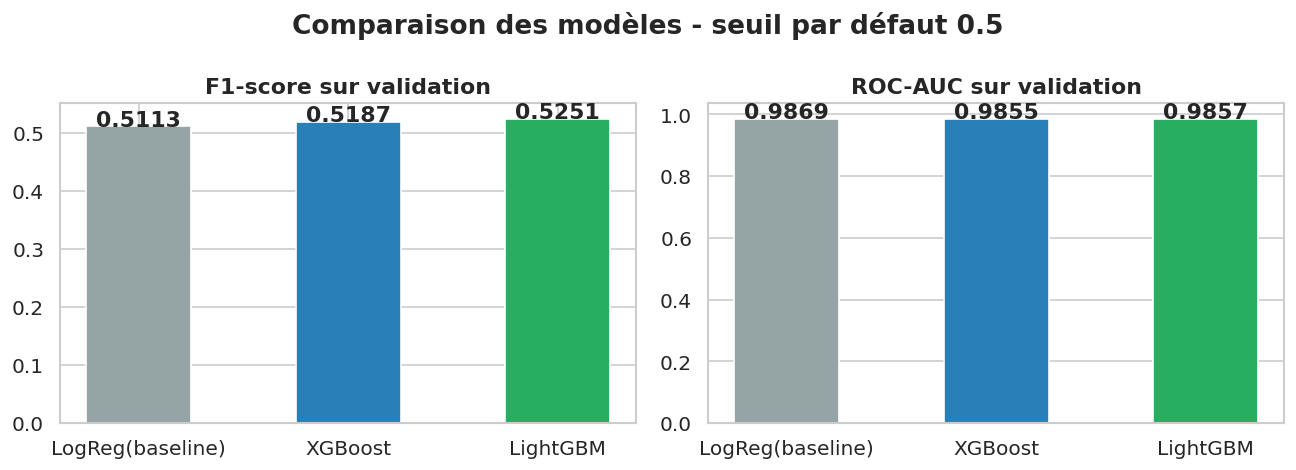

In [8]:
models_info = {
    'LogReg(baseline)': (y_proba_lr,   '#95a5a6'),
    'XGBoost': (y_proba_xgb,  '#2980b9'),
    'LightGBM': (y_proba_lgbm, '#27ae60'),
}
f1s  = {k: f1_score(y_val, (p >= 0.5).astype(int)) for k,(p,_) in models_info.items()}
aucs = {k: roc_auc_score(y_val, p)                  for k,(p,_) in models_info.items()}

summary = pd.DataFrame({'F1-score': f1s, 'ROC-AUC': aucs})
display(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = [v[1] for v in models_info.values()]
for ax, (metric, vals) in zip(axes, [('F1-score', f1s), ('ROC-AUC', aucs)]):
    bars = ax.bar(vals.keys(), vals.values(), color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} sur validation', fontweight='bold')
    for bar, v in zip(bars, vals.values()):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')
plt.suptitle('Comparaison des modèles - seuil par défaut 0.5', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_image_path}/m01_model_comparison.png', bbox_inches='tight')
plt.show()

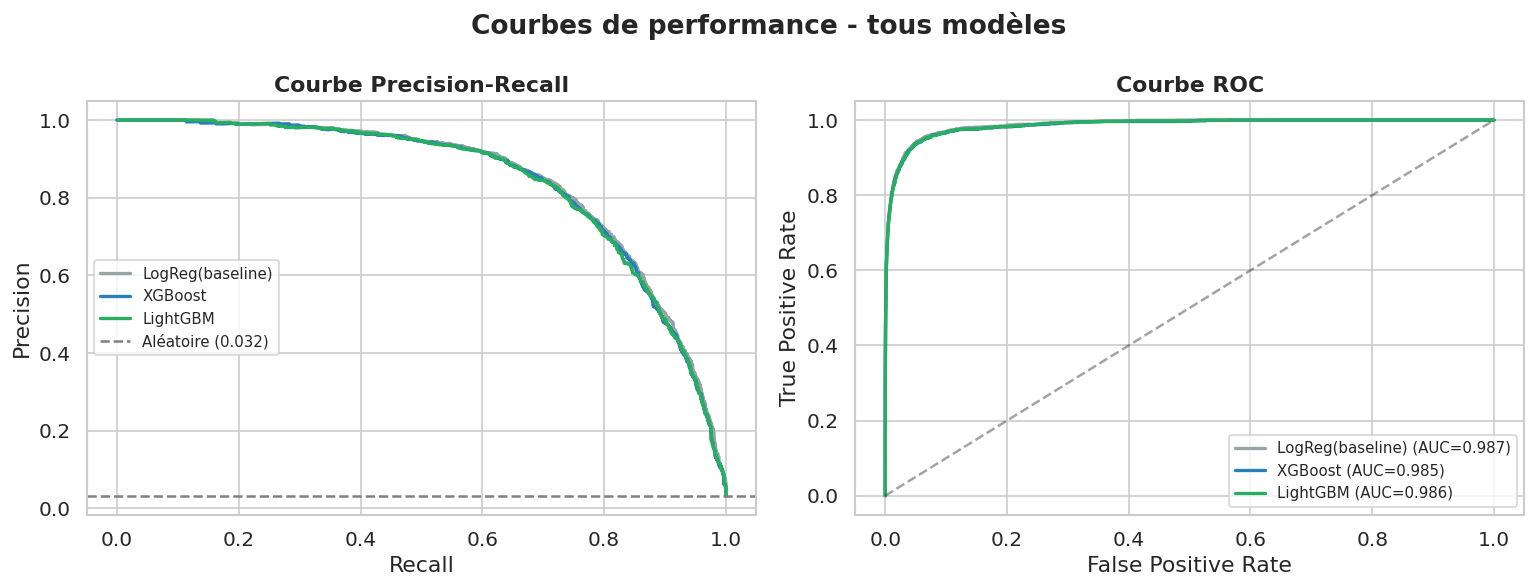

In [9]:
# Courbes PR et ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, (proba, color) in models_info.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    fpr, tpr, _  = roc_curve(y_val, proba)
    axes[0].plot(rec, prec, label=name, color=color, lw=2)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})', color=color, lw=2)

axes[0].axhline(y_val.mean(), color='gray', linestyle='--', label=f'Aléatoire ({y_val.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Courbe Precision-Recall', fontweight='bold'); axes[0].legend(fontsize=9)

axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC', fontweight='bold'); axes[1].legend(fontsize=9)

plt.suptitle('Courbes de performance - tous modèles', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_image_path}/m02_pr_roc_curves.png', bbox_inches='tight')
plt.show()

### **6. Optimisation du seuil de décision**

Avec un fort déséquilibre de classes, le seuil par défaut (0.5) est rarement optimal pour le F1.
On balaye tous les seuils pour trouver celui qui maximise le F1 sur la validation.

XGBoost - seuil optimal : 0.95 => F1 : 0.7706
LightGBM - seuil optimal : 0.95 => F1 : 0.7676


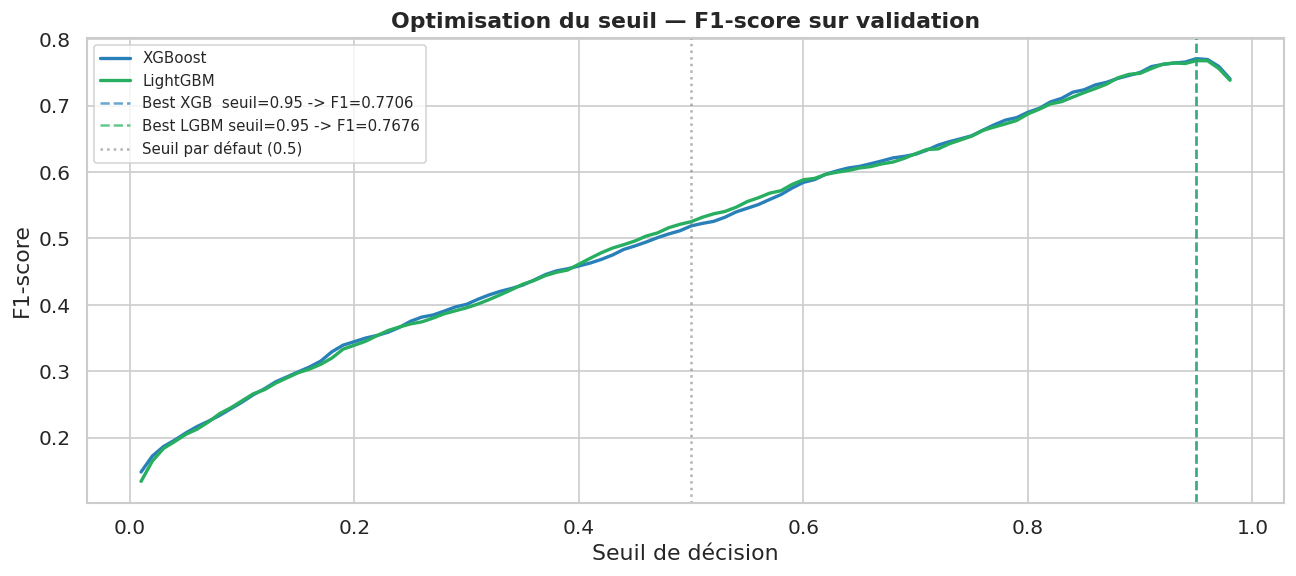

In [11]:
thresholds = np.arange(0.01, 0.99, 0.01)

f1_xgb  = [f1_score(y_val, (y_proba_xgb  >= t).astype(int)) for t in thresholds]
f1_lgbm = [f1_score(y_val, (y_proba_lgbm >= t).astype(int)) for t in thresholds]

best_thresh_xgb  = thresholds[np.argmax(f1_xgb)]
best_thresh_lgbm = thresholds[np.argmax(f1_lgbm)]
best_f1_xgb      = max(f1_xgb)
best_f1_lgbm     = max(f1_lgbm)

print(f'XGBoost - seuil optimal : {best_thresh_xgb:.2f} => F1 : {best_f1_xgb:.4f}')
print(f'LightGBM - seuil optimal : {best_thresh_lgbm:.2f} => F1 : {best_f1_lgbm:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(thresholds, f1_xgb,  color='#2980b9', lw=2, label='XGBoost')
ax.plot(thresholds, f1_lgbm, color='#27ae60', lw=2, label='LightGBM')
ax.axvline(best_thresh_xgb,  color='#2980b9', linestyle='--', alpha=0.7,
           label=f'Best XGB  seuil={best_thresh_xgb:.2f} -> F1={best_f1_xgb:.4f}')
ax.axvline(best_thresh_lgbm, color='#27ae60', linestyle='--', alpha=0.7,
           label=f'Best LGBM seuil={best_thresh_lgbm:.2f} -> F1={best_f1_lgbm:.4f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='Seuil par défaut (0.5)')

ax.set_xlabel('Seuil de décision'); ax.set_ylabel('F1-score')
ax.set_title('Optimisation du seuil — F1-score sur validation', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{output_image_path}/m03_threshold_optimization.png', bbox_inches='tight')
plt.show()

### **7. Évaluation finale - meilleur modèle avec seuil optimisé**

In [12]:
# Sélection du meilleur modèle
if best_f1_xgb >= best_f1_lgbm:
    best_model_name = 'XGBoost'
    best_proba = y_proba_xgb
    best_thresh = best_thresh_xgb
    best_f1 = best_f1_xgb
    best_model  = xgb
else:
    best_model_name = 'LightGBM'
    best_proba = y_proba_lgbm
    best_thresh = best_thresh_lgbm
    best_f1 = best_f1_lgbm
    best_model = lgbm

print(f'Meilleur modèle : {best_model_name}')
print(f'Seuil optimisé  : {best_thresh:.2f}')
print(f'F1 final (val)  : {best_f1:.4f}')

# Rapport complet
y_pred_best = (best_proba >= best_thresh).astype(int)
print()
print(classification_report(y_val, y_pred_best))

Meilleur modèle : XGBoost
Seuil optimisé  : 0.95
F1 final (val)  : 0.7706

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55080
           1       0.80      0.74      0.77      1836

    accuracy                           0.99     56916
   macro avg       0.90      0.87      0.88     56916
weighted avg       0.99      0.99      0.99     56916



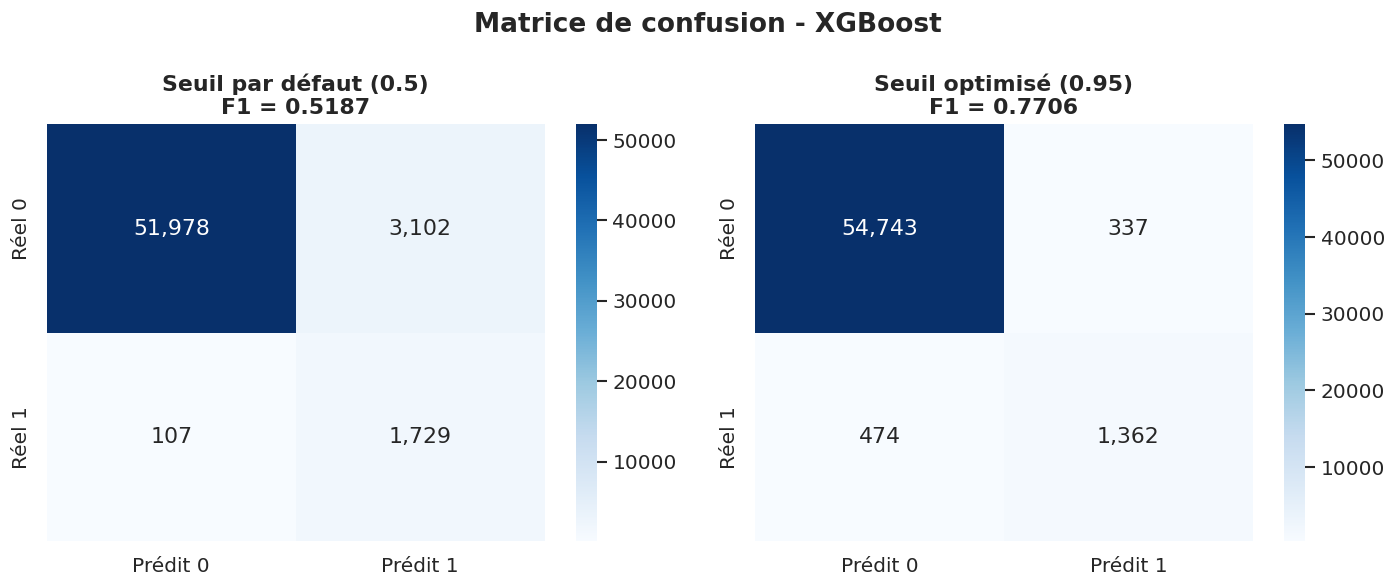

In [13]:
# Matrices de confusion : seuil 0.5 vs seuil optimisé
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (thresh, label) in zip(axes, [
    (0.5, 'Seuil par défaut (0.5)'),
    (best_thresh, f'Seuil optimisé ({best_thresh:.2f})')
]):
    y_pred = (best_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'])
    ax.set_title(f'{label}\nF1 = {f1:.4f}', fontweight='bold')

plt.suptitle(f'Matrice de confusion - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_image_path}/m04_confusion_matrices.png', bbox_inches='tight')
plt.show()

### **8. Feature Importance**

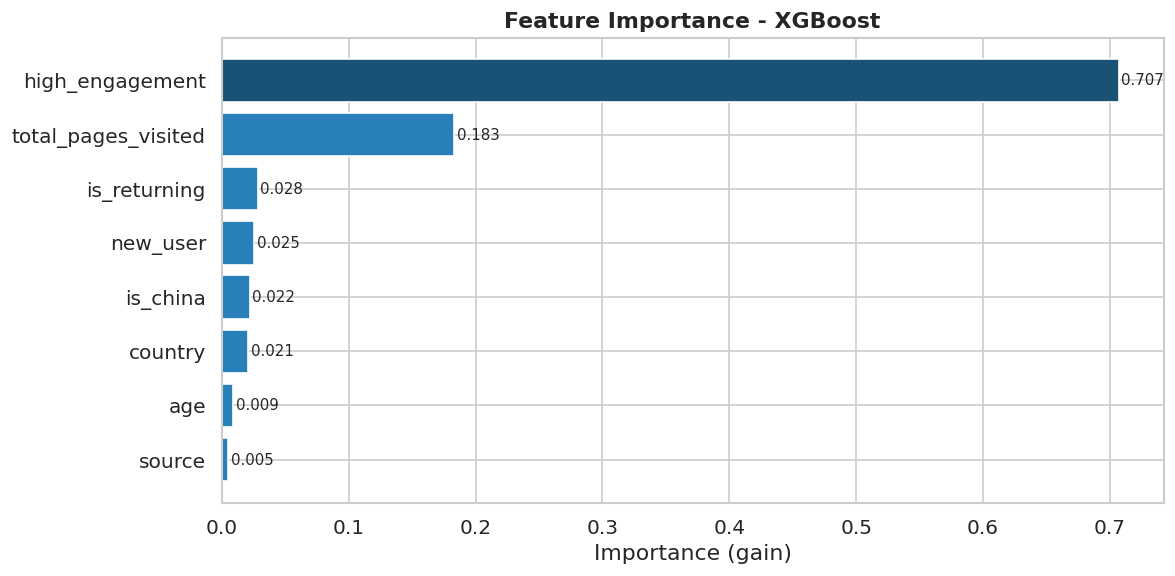

In [15]:
importances = xgb.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_imps  = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 5))

colors_feat = ['#1a5276' if imp == max(importances) else '#2980b9' for imp in sorted_imps]
bars = ax.barh(range(len(sorted_names)), sorted_imps[::-1],
               color=colors_feat[::-1], edgecolor='white')
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names[::-1])
ax.set_xlabel('Importance (gain)')
ax.set_title('Feature Importance - XGBoost', fontweight='bold')

for bar, v in zip(bars, sorted_imps[::-1]):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{output_image_path}/m05_feature_importance.png', bbox_inches='tight')
plt.show()

### **9. Sauvegarde du meilleur modèle**

In [16]:
with open(f'{output_model_path}/best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'threshold': best_thresh, 'name': best_model_name}, f)

with open(f'{output_model_path}/logreg_baseline.pkl', 'wb') as f:
    pickle.dump(logreg, f)

np.save(f'{output_processed_path}/y_val_proba_best.npy', best_proba)

print(f'{output_model_path}/best_model.pkl - ({best_model_name}, seuil={best_thresh:.2f})')
print(f'{output_model_path}/logreg_baseline.pkl  (baseline)')
print(f'{output_processed_path}/y_val_proba_best.npy (probabilités val)')

../outputs/models/best_model.pkl - (XGBoost, seuil=0.95)
../outputs/models/logreg_baseline.pkl  (baseline)
../outputs/processed/y_val_proba_best.npy (probabilités val)
